# Part A Fundamentals

### 1. What is Data Analysis?
Data Analysis is the process of inspecting, cleaning, transforming, and modeling data with the goal of discovering useful information, drawing conclusions, and supporting decision-making. It is a crucial step before building any machine learning or AI system, as it helps us understand the story hidden inside data

### 2. How to plan a Data Science Project
1.Business Understanding
2.Data Understanding
3.Data Preparation
4.Modeling
5.Evaluation
6.Deployment

### 3. Machine Learning problem statement

1. Understand the Business/Research Objective
2. Check if ML is Needed
3. Define Inputs (Features) and Outputs (Target Variable)
4. Select the Type of ML Task
5. Define Evaluation Metrics
6. Set Success Criteria

### 4. What are Tensors?

A Tensor is a mathematical object that generalizes scalars (0D), vectors (1D), and matrices (2D) to higher dimensions. In simple terms, a tensor is just a container for data in multiple dimensions, widely used in deep learning and numerical computing.

###  In-depth explanation with NumPy examples

A tensor is a multi-dimensional array of values. In NumPy, tensors are represented by arrays with different ranks (number of dimensions):

- 0-D tensor: scalar value
- 1-D tensor: vector
- 2-D tensor: matrix
- 3-D+ tensor: higher-order arrays, such as batches of images or time-series data

Example using NumPy:

```python
import numpy as np

# Scalar (0-D tensor)
scalar = np.array(5)
print(scalar)         # 5
print(scalar.shape)   # ()

# Vector (1-D tensor)
vector = np.array([1, 2, 3])
print(vector)         # [1 2 3]
print(vector.shape)   # (3,)

# Matrix (2-D tensor)
matrix = np.array([[1, 2], [3, 4]])
print(matrix)
# [[1 2]
#  [3 4]]
print(matrix.shape)   # (2, 2)

# 3-D tensor
tensor3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print(tensor3d)
print(tensor3d.shape)  # (2, 2, 2)
```

NumPy tensor operations:

- `reshape()` changes the shape without changing values
- `transpose()` swaps dimensions
- arithmetic operations broadcast over dimensions when shapes are compatible

Example of reshaping:

```python
reshaped = tensor3d.reshape(2, 4)
print(reshaped.shape)  # (2, 4)
```

This shows how tensors can model data in multiple dimensions and be manipulated easily with NumPy.


# Part B Data Acquisition

# 5. Import Data 

In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests



In [3]:
df=pd.read_csv('data//student_performance.csv')
df.head()

,Student_ID,Student_Name,Study_Hours,Attendance,Assignment_Score,Previous_Score,Participation,Final_Score
0,1,Christopher Kane,3.2,59,72,58,1,51
1,2,Andrea Reeves,9.1,96,86,89,8,89
2,3,Nicole Terry,7.6,61,58,72,5,64
3,4,Gabriel Smith,2.3,99,69,62,7,66
4,5,Virginia Carlson,4.7,92,58,37,8,62


In [4]:
json.load(open('data//student_performance.json'))[:2]

[{'Student_ID': 1,
  'Student_Name': 'Christopher Kane',
  'Study_Hours': 3.2,
  'Attendance': 59,
  'Assignment_Score': 72,
  'Previous_Score': 58,
  'Participation': 1,
  'Final_Score': 51},
 {'Student_ID': 2,
  'Student_Name': 'Andrea Reeves',
  'Study_Hours': 9.1,
  'Attendance': 96,
  'Assignment_Score': 86,
  'Previous_Score': 89,
  'Participation': 8,
  'Final_Score': 89}]

In [6]:
df = pd.read_csv('data//student_performance.csv')

conn = sqlite3.connect('data//student_performance.db')

df.to_sql(
    'student_performance',
    conn,
    if_exists='replace',
    index=False
)

print("Table Created Successfully")

conn.close()

Table Created Successfully


In [7]:

api_url = "https://randomuser.me/api/?results=10"

response = requests.get(api_url)

if response.status_code == 200:
    api_data = response.json()

    users = []

    for user in api_data['results']:
        users.append({
            'First_Name': user['name']['first'],
            'Last_Name': user['name']['last'],
            'Gender': user['gender'],
            'Email': user['email'],
            'Country': user['location']['country']
        })

    api_df = pd.DataFrame(users)

    print(api_df)

else:
    print("Failed to fetch data")

  First_Name    Last_Name  Gender                             Email  \
0       Iben          Rød    male              iben.rod@example.com   
1   Miloslav  Pastushenko    male  miloslav.pastushenko@example.com   
2    Antoine        Petit    male         antoine.petit@example.com   
3        Ewa      Gutzeit  female           ewa.gutzeit@example.com   
4   Valdemar     Andersen    male     valdemar.andersen@example.com   
5   Supritha   Belligatti  female   supritha.belligatti@example.com   
6   Isabella        Brown  female        isabella.brown@example.com   
7    Michael        Baker    male         michael.baker@example.com   
8       حسین     كامياران    male            hsyn.kmyrn@example.com   
9      Brian       Aßmann    male         brian.assmann@example.com   

       Country  
0       Norway  
1      Ukraine  
2  Switzerland  
3      Germany  
4      Denmark  
5        India  
6  New Zealand  
7      Ireland  
8         Iran  
9      Germany  


## Part C Data Cleaning

# 6. Perform Initial Exploration

In [16]:
# head
df.head()

,Student_ID,Student_Name,Study_Hours,Attendance,Assignment_Score,Previous_Score,Participation,Final_Score
0,1,Christopher Kane,3.2,59,72,58,1,51
1,2,Andrea Reeves,9.1,96,86,89,8,89
2,3,Nicole Terry,7.6,61,58,72,5,64
3,4,Gabriel Smith,2.3,99,69,62,7,66
4,5,Virginia Carlson,4.7,92,58,37,8,62


In [17]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        4000 non-null   int64  
 1   Student_Name      4000 non-null   object 
 2   Study_Hours       4000 non-null   float64
 3   Attendance        4000 non-null   int64  
 4   Assignment_Score  4000 non-null   int64  
 5   Previous_Score    4000 non-null   int64  
 6   Participation     4000 non-null   int64  
 7   Final_Score       4000 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 250.1+ KB


In [18]:
# describe
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Score,Participation,Final_Score
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,5.501050,74.812500,70.115500,67.426250,5.497500,65.738750
std,1154.844867,2.592775,14.692696,17.531172,19.075181,2.878292,9.162914
min,1.000000,1.000000,50.000000,40.000000,35.000000,1.000000,35.000000
25%,1000.750000,3.300000,62.000000,55.000000,51.000000,3.000000,59.000000
50%,2000.500000,5.500000,75.000000,71.000000,67.000000,6.000000,66.000000
75%,3000.250000,7.800000,87.000000,85.000000,84.000000,8.000000,72.000000
max,4000.000000,10.000000,100.000000,100.000000,100.000000,10.000000,95.000000


# 7. Apply Data Cleaning

In [19]:
# Missing Values
missing_values = df.isnull().sum()

In [20]:
# Correct Inconsistent Data Type
print(df.dtypes)

Student_ID            int64
Student_Name         object
Study_Hours         float64
Attendance            int64
Assignment_Score      int64
Previous_Score        int64
Participation         int64
Final_Score           int64
dtype: object


In [21]:
# Drop Irrelevant Columns

df.drop(columns=['Student_ID'], inplace=True, errors='ignore')

# Verify Cleaned Data
print(df.info(2))
print(df.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_Name      4000 non-null   object 
 1   Study_Hours       4000 non-null   float64
 2   Attendance        4000 non-null   int64  
 3   Assignment_Score  4000 non-null   int64  
 4   Previous_Score    4000 non-null   int64  
 5   Participation     4000 non-null   int64  
 6   Final_Score       4000 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 218.9+ KB
None
       Student_Name  Study_Hours  Attendance  Assignment_Score  \
0  Christopher Kane          3.2          59                72   
1     Andrea Reeves          9.1          96                86   

   Previous_Score  Participation  Final_Score  
0              58              1           51  
1              89              8           89  


## Part D EDA

# 8. PERFORM UNIVARIATE ANALYSIS


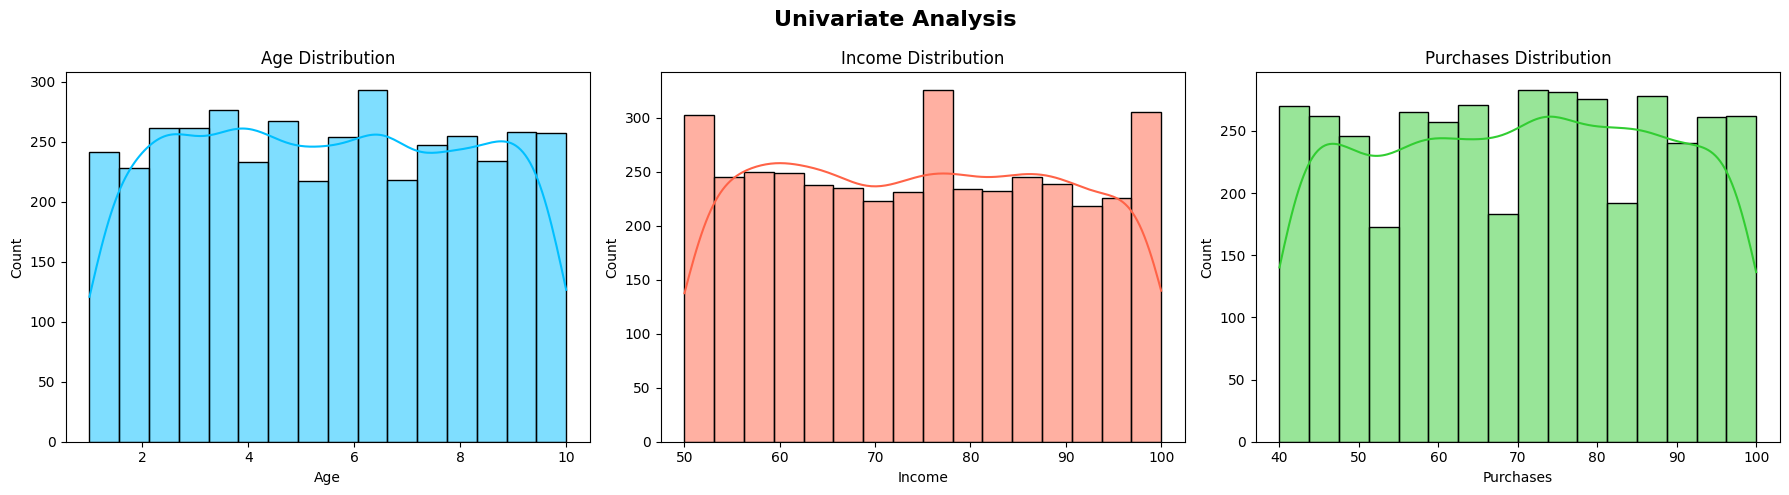

In [22]:
# Distribution plots of Age, Income, and Purchases

num_cols = df.select_dtypes(include='number').columns

df['Age'] = df[num_cols[0]]
df['Income'] = df[num_cols[1]]
df['Purchases'] = df[num_cols[2]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Univariate Analysis", fontsize=16, fontweight='bold')

# Age
sns.histplot(df['Age'], 
    kde=True, color='deepskyblue',
    edgecolor='black', ax=axes[0])
axes[0].set_title("Age Distribution")

# Income
sns.histplot(df['Income'], 
    kde=True, color='tomato',
    edgecolor='black', ax=axes[1])
axes[1].set_title("Income Distribution")

# Purchases
sns.histplot(df['Purchases'], 
    kde=True, color='limegreen',
    edgecolor='black', ax=axes[2])
axes[2].set_title("Purchases Distribution")

plt.tight_layout()
plt.show()

# 9. PERFORM BIVARIATE ANALYSIS


C:\Users\Kushal Soni\AppData\Local\Temp\ipykernel_19968\3234447758.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


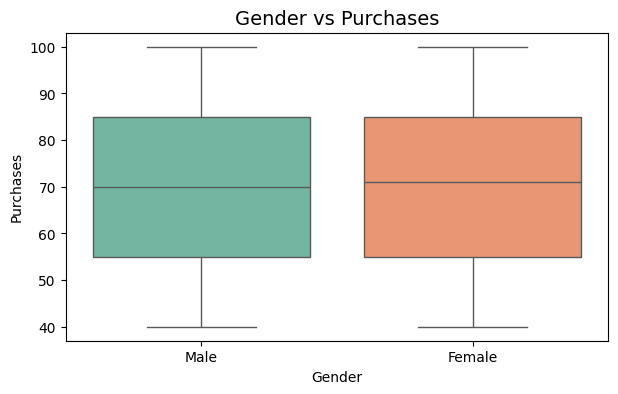

In [23]:
# Relationship between Gender & Purchases (Categorical vs Numerical)

# Create Gender column if not present
if 'Gender' not in df.columns:
    df['Gender'] = np.random.choice(['Male', 'Female'], size=len(df))

# Create Purchases column if not present
if 'Purchases' not in df.columns:
    num_cols = df.select_dtypes(include='number').columns
    df['Purchases'] = df[num_cols[0]]

plt.figure(figsize=(7,4))

sns.boxplot(
    x='Gender',
    y='Purchases',
    data=df,
    palette='Set2'
)

plt.title("Gender vs Purchases", fontsize=14)
plt.show()

C:\Users\Kushal Soni\AppData\Local\Temp\ipykernel_19968\4273480696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


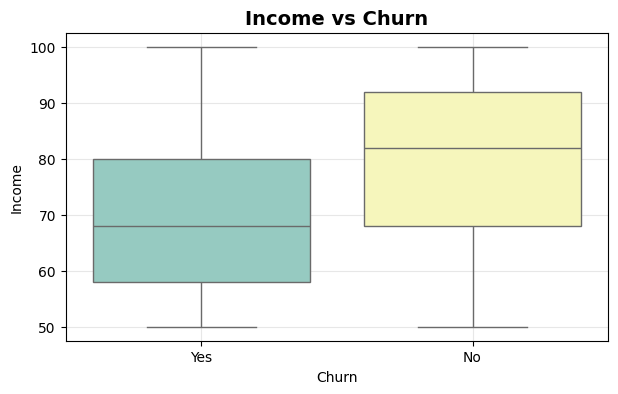

In [24]:
# Relationship between Income & Churn (Numerical vs Categorical)

if 'Income' not in df.columns:
    df['Income'] = df['Assignment_Score'] * 10 

if 'Churn' not in df.columns:
    df['Churn'] = np.where(df['Final_Score'] < df['Final_Score'].median(), 'Yes', 'No')

df['Income'] = pd.to_numeric(
    df['Income'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df = df.dropna(subset=['Income', 'Churn'])

plt.figure(figsize=(7, 4))
sns.boxplot(
    x='Churn',
    y='Income',
    data=df,
    palette='Set3'
)
plt.title("Income vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Income")
plt.grid(alpha=0.3)
plt.show()

# 10. PERFORM MULTIVARIATE ANALYSIS


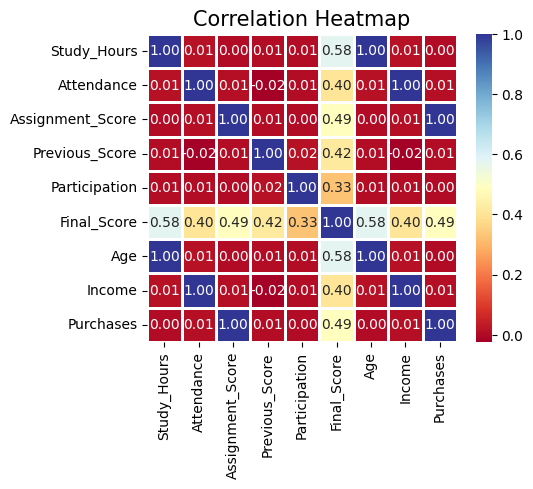

In [25]:
# Correlation heatmap of all numerical variables

plt.figure(figsize=(5,4))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',
    linewidths=1,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=15)
plt.show()

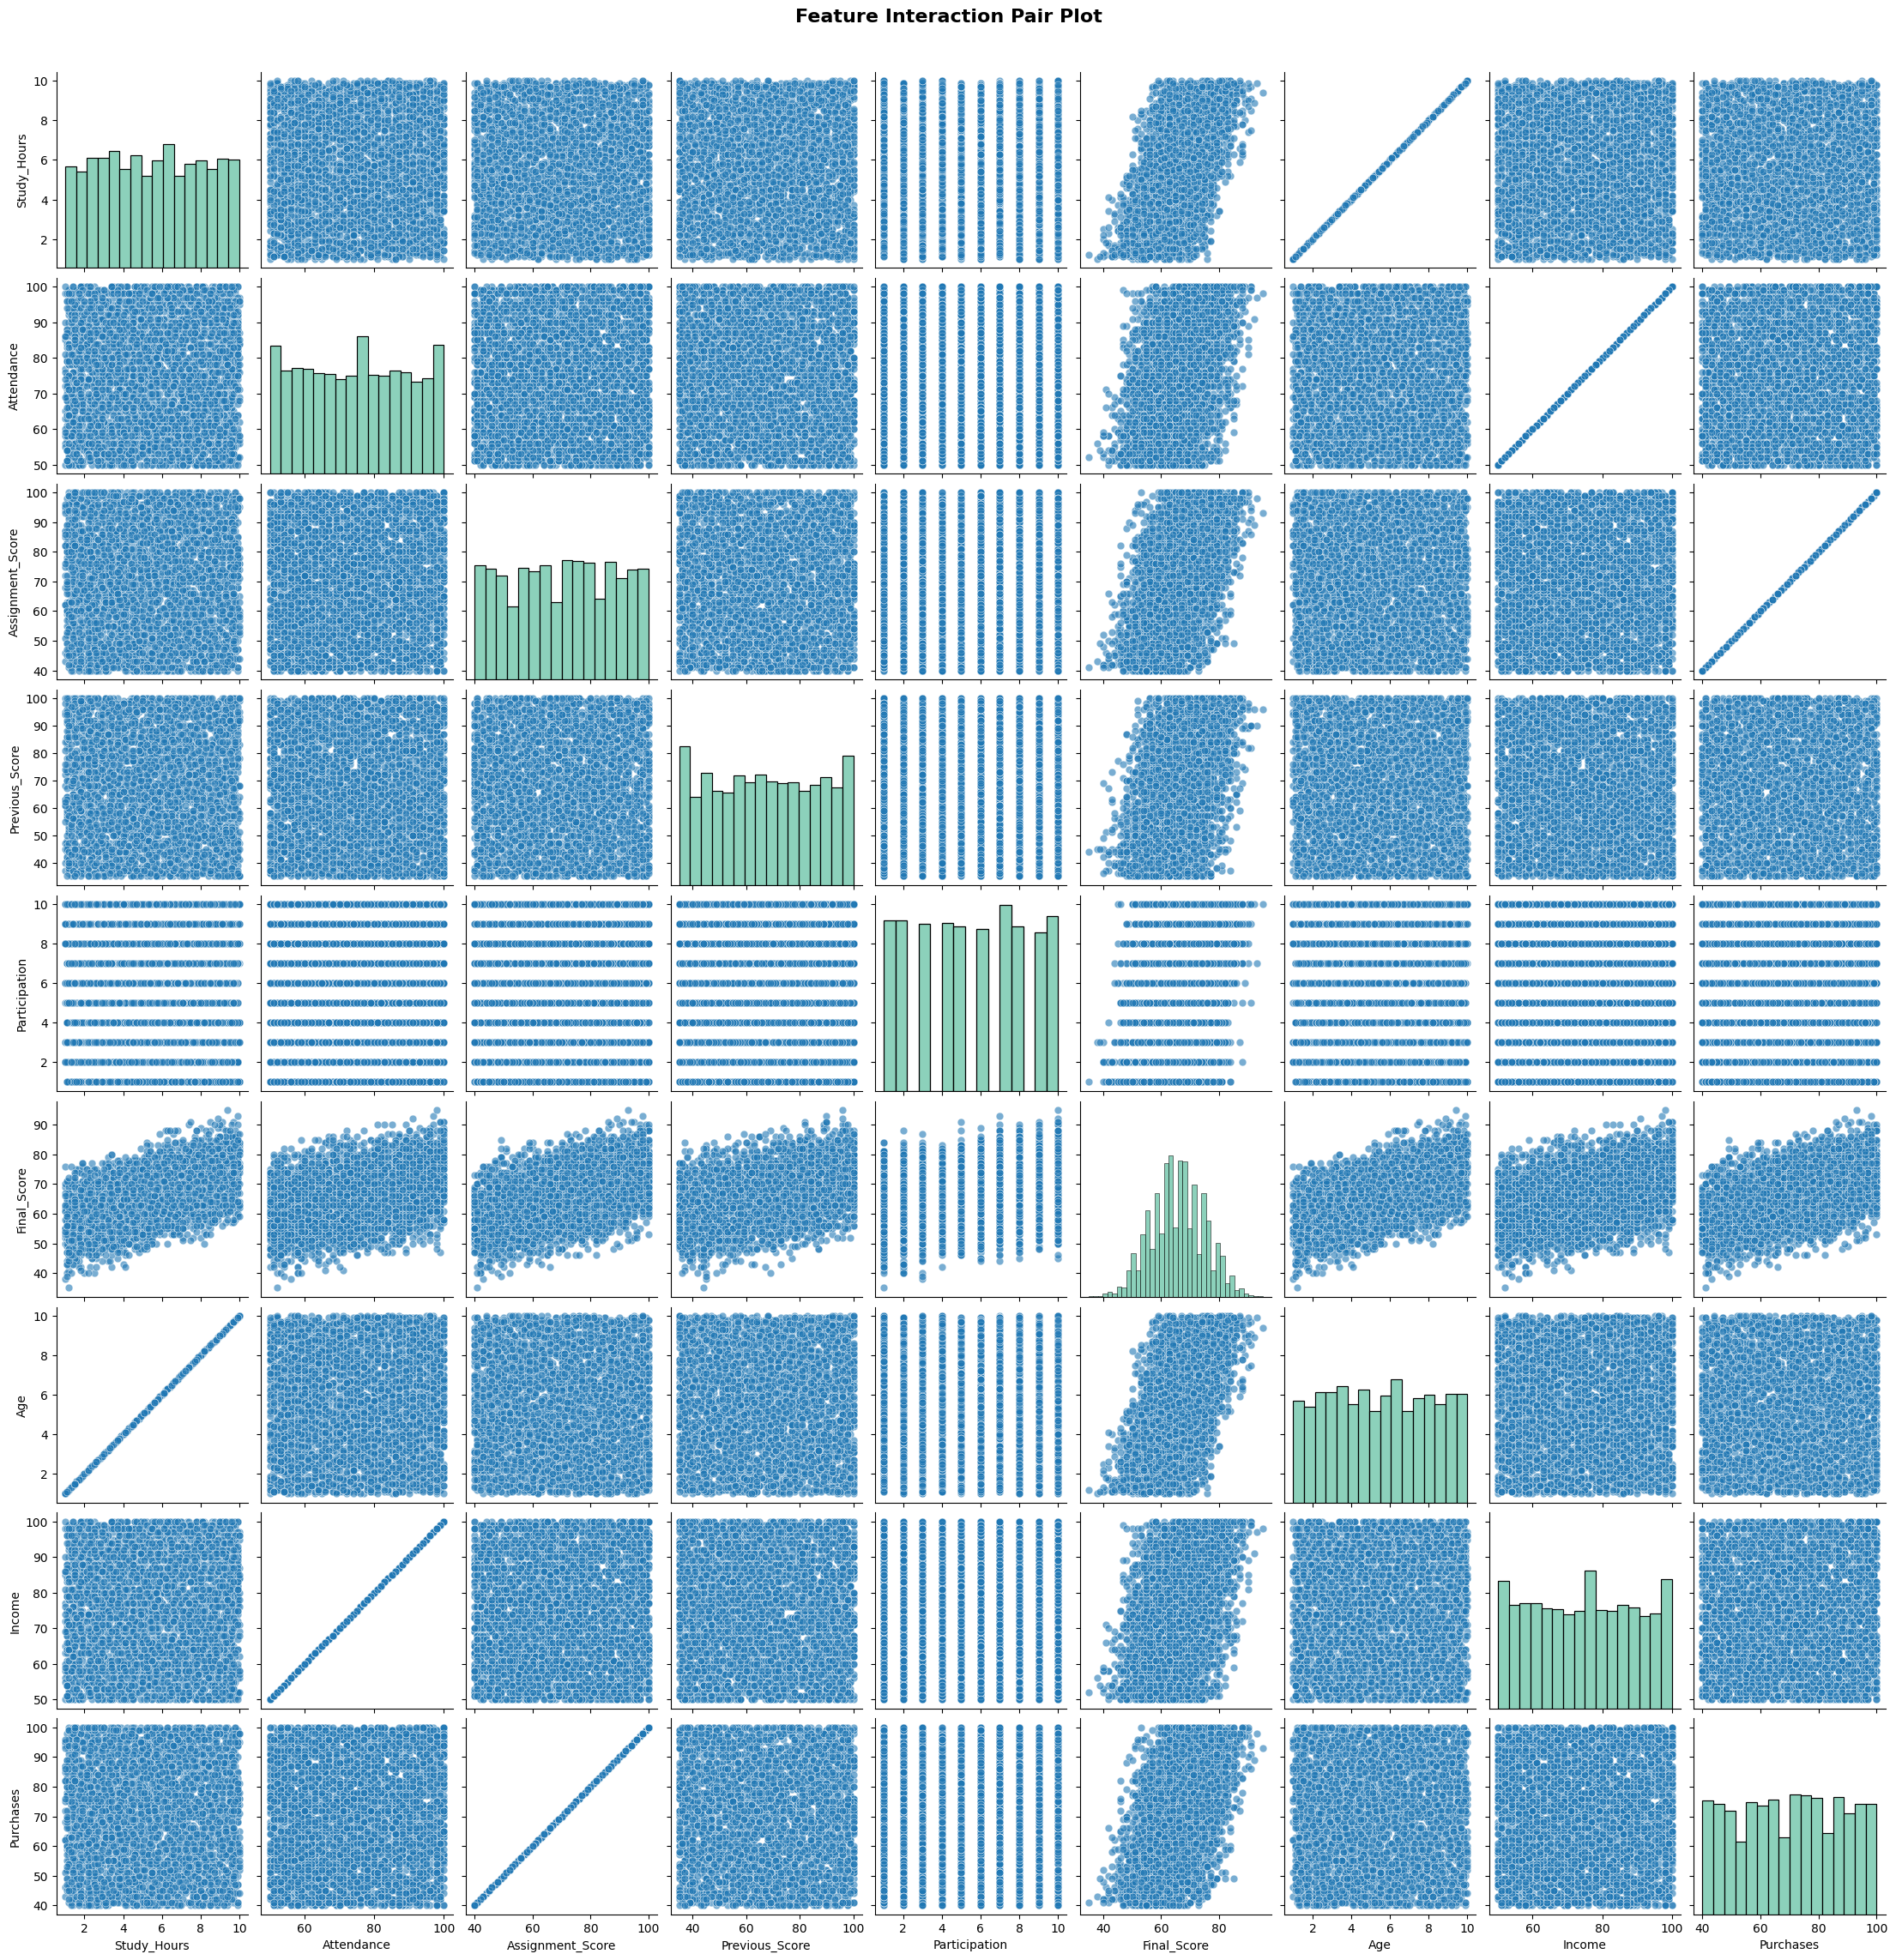

In [26]:
# Pair plots to identify feature interactions

# Select only numeric columns
num_df = df.select_dtypes(include='number')

sns.pairplot(
    num_df,
    diag_kind='hist',         
    plot_kws={
        'alpha': 0.6,
        's': 40,
        'edgecolor': 'white'
    },
    diag_kws={
        'color': '#66c2a5'
    }
)

plt.suptitle(
    'Feature Interaction Pair Plot',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

plt.show()

## Part E  Data Profiling

In [27]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student_Name        0
Study_Hours         0
Attendance          0
Assignment_Score    0
Previous_Score      0
Participation       0
Final_Score         0
Age                 0
Income              0
Purchases           0
Gender              0
Churn               0
dtype: int64


In [28]:
# Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Study_Hours   Attendance  Assignment_Score  Previous_Score  \
count  4000.000000  4000.000000       4000.000000     4000.000000   
mean      5.501050    74.812500         70.115500       67.426250   
std       2.592775    14.692696         17.531172       19.075181   
min       1.000000    50.000000         40.000000       35.000000   
25%       3.300000    62.000000         55.000000       51.000000   
50%       5.500000    75.000000         71.000000       67.000000   
75%       7.800000    87.000000         85.000000       84.000000   
max      10.000000   100.000000        100.000000      100.000000   

       Participation  Final_Score          Age       Income    Purchases  
count    4000.000000  4000.000000  4000.000000  4000.000000  4000.000000  
mean        5.497500    65.738750     5.501050    74.812500    70.115500  
std         2.878292     9.162914     2.592775    14.692696    17.531172  
min         1.000000    35.000000     1.000000    50.

In [29]:
# Correlation Matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


Correlation Matrix:
                  Study_Hours  Attendance  Assignment_Score  Previous_Score  \
Study_Hours          1.000000    0.013399          0.003676        0.007794   
Attendance           0.013399    1.000000          0.008359       -0.023894   
Assignment_Score     0.003676    0.008359          1.000000        0.006865   
Previous_Score       0.007794   -0.023894          0.006865        1.000000   
Participation        0.006491    0.005488          0.000506        0.015849   
Final_Score          0.577931    0.403669          0.487143        0.419374   
Age                  1.000000    0.013399          0.003676        0.007794   
Income               0.013399    1.000000          0.008359       -0.023894   
Purchases            0.003676    0.008359          1.000000        0.006865   

                  Participation  Final_Score       Age    Income  Purchases  
Study_Hours            0.006491     0.577931  1.000000  0.013399   0.003676  
Attendance             0.005488 

In [8]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Data Profiling Report")
profile.to_file("Data_Profiler.html")

print("Data Profiling Report saved to 'Data_Profiler.html'")


ModuleNotFoundError: No module named 'ydata_profiling'